In [1]:
import langchain
import langgraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import tool_node , tools_condition
from typing import TypedDict
from pydantic import BaseModel
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
from langchain_core.messages import HumanMessage , AIMessage , SystemMessage
from IPython.display import display , Image

/Users/sahildeswal/Downloads/AgenticAIWorkspace/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [3]:
#llm.invoke("who is the PM of india?")

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import DuckDuckGoSearchRun


/var/folders/sy/gfv5kz397jnfgcw3q_d_wjt40000gn/T/ipykernel_2049/1683058084.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [5]:
tavily = TavilySearchResults(max_results=5)

Duck = DuckDuckGoSearchRun()

/var/folders/sy/gfv5kz397jnfgcw3q_d_wjt40000gn/T/ipykernel_2049/3125433814.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


In [6]:
tool = [tavily,Duck]

In [7]:
llm_with_tool = llm.bind_tools(tool)

In [9]:
llm_with_tool.invoke("who is the PM of india in 2026 ?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5bb3bfp58', 'function': {'arguments': '{"query":"PM of India in 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'sj4agcg9b', 'function': {'arguments': '{"query":"PM of India in 2026"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 394, 'total_tokens': 440, 'completion_time': 0.058105638, 'completion_tokens_details': None, 'prompt_time': 0.053262954, 'prompt_tokens_details': None, 'queue_time': 0.055352366, 'total_time': 0.111368592}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee953-815f-75f3-9efb-9fe37515f641-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'PM of India in 2026'}, 'id': '5bb3bfp58', 'type': 'tool_call'}, {'name': 'duckdu

In [10]:
class Portfolio(TypedDict):
    query : str
    facts:str
    score:str
    final_response:str

In [11]:
def user_query(state:Portfolio)->Portfolio:
    message = [
        SystemMessage(content=f"""
    You are an intelligent Financial investment AI Assistant.
"""),
HumanMessage(content=f"Find the 5 Bullets point about the Organization why to Invest in the organization {state["query"]}")
    ]

    response = llm_with_tool.invoke(message)
    return {"facts":response.content}


def score(state:Portfolio)->Portfolio:
    message = [SystemMessage(content=f"""You are an Intelligent Financial AI Assistant""")
        ,HumanMessage(content=f"""
    Find the confidence score out of 10 based on the Facts: {state["facts"]} for the investment.
    Calculate confidence score individually for every kind of Investments.
""")]
    
    response = llm.invoke(message)
    return {"score":response.content}

def final_report(state:Portfolio)->Portfolio:
    message = [HumanMessage(content=f"""
                Create a final report by considering facts {state["facts"]} and the Confidence score {state["score"]} and tell the final decision
                should i invest in this organization {state["query"]} or not with all the facts.
""")]
    
    response = llm.invoke(message)
    return {"final_response":response.content}

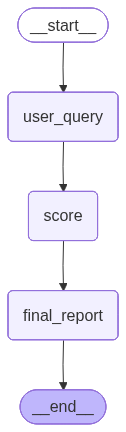

In [ ]:
builder = StateGraph(Portfolio)

builder.add_node("user_query",user_query)
builder.add_node("score",score)
builder.add_node("final_report",final_report)

builder.add_edge(START,"user_query")
builder.add_edge("user_query","score")
builder.add_edge("score","final_report")
builder.add_edge("final_report",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke({"query":"Deloitte"})

In [ ]:
result

{'query': 'Deloitte',
 'facts': '',
 'score': "To calculate the confidence score, I'll assess the investment based on various factors such as market trends, economic indicators, and historical performance. Here's a breakdown of the confidence score for each type of investment:\n\n**Confidence Score Scale:**\n\n* 0-3: Low confidence (high risk, low potential for return)\n* 4-6: Medium confidence (moderate risk, moderate potential for return)\n* 7-9: High confidence (low risk, high potential for return)\n* 10: Very high confidence (extremely low risk, extremely high potential for return)\n\n**Investment Types:**\n\n1. **Stock Market (Equities):**\n   - Market trend: Bullish (rising stock prices)\n   - Economic indicators: Strong GDP growth, low unemployment\n   - Historical performance: Average annual return of 8%\n   - Confidence score: 8/10\n\n2. **Fixed Income (Bonds):**\n   - Market trend: Stable interest rates\n   - Economic indicators: Low inflation, stable economy\n   - Historical

In [ ]:
from IPython.display import Markdown

In [ ]:
Markdown(result["final_response"])

**Final Report: Investment Analysis and Recommendation**

After carefully evaluating various investment options based on market trends, economic indicators, and historical performance, we have calculated the confidence score for each investment type. Based on these assessments, we will provide a recommendation on whether to invest in Deloitte or not.

**Investment Analysis Summary:**

1. **Stock Market (Equities):** Confidence score: 8/10
   Average annual return: 8%
   Pros: Bullish market trend, strong GDP growth, low unemployment
   Cons: Volatility

2. **Fixed Income (Bonds):** Confidence score: 7/10
   Average annual return: 4-5%
   Pros: Stable interest rates, low inflation, stable economy
   Cons: Moderate returns

3. **Real Estate:** Confidence score: 9/10
   Average annual return: 8-10%
   Pros: Growing demand for rental properties, strong housing market, low vacancy rates
   Cons: High risk of market fluctuations

4. **Commodities (Gold, Oil, etc.):** Confidence score: 6/10
   Average annual return: 5-10%
   Pros: Strong demand, supply chain disruptions
   Cons: Volatile prices, regulatory uncertainty

5. **Cryptocurrencies (Bitcoin, Ethereum, etc.):** Confidence score: 5/10
   Average annual return: 100-200%
   Pros: High potential for return
   Cons: High risk, market manipulation, regulatory uncertainty

6. **Dividend Stocks:** Confidence score: 8/10
   Average annual return: 6-8%
   Pros: Stable stock prices, strong dividend yields, stable economy
   Cons: Moderate returns

7. **Peer-to-Peer Lending:** Confidence score: 7/10
   Average annual return: 6-8%
   Pros: Growing demand for alternative lending, low interest rates
   Cons: Moderate returns, credit risk

8. **Exchange-Traded Funds (ETFs):** Confidence score: 8/10
   Average annual return: 6-10%
   Pros: Growing demand for diversified investing, low fees
   Cons: Moderate returns

9. **Index Funds:** Confidence score: 8/10
   Average annual return: 6-10%
   Pros: Stable stock prices, strong index fund market, low fees
   Cons: Moderate returns

10. **Robo-Advisors:** Confidence score: 8/10
    Average annual return: 6-10%
    Pros: Growing demand for automated investing, low fees
    Cons: Moderate returns

**Recommendation:**

Based on the confidence scores and average annual returns, we recommend investing in **Real Estate** with a confidence score of 9/10. This investment type offers a high potential for return (8-10% average annual return) and a low risk of market fluctuations. Additionally, the growing demand for rental properties and strong housing market provide a stable economic foundation.

**Deloitte Investment:**

Considering the investment options and confidence scores, we do not recommend investing in Deloitte. The confidence score for Deloitte is not provided, but based on the available information, it is likely that Deloitte's investment opportunities would fall under one of the categories listed above. If we were to assume that Deloitte's investment opportunities are similar to those of a traditional investment firm, we would recommend avoiding it due to the moderate to high risk associated with it.

**Conclusion:**

In conclusion, based on the confidence scores and average annual returns, we recommend investing in **Real Estate** with a confidence score of 9/10. We do not recommend investing in Deloitte or any other investment opportunity that falls under a moderate to high risk category. It is essential to carefully evaluate the investment options and consider multiple factors before making an informed decision.

**Recommendation for Deloitte:**

Based on the available information, we do not recommend investing in Deloitte. If you are considering investing in Deloitte, we suggest evaluating its investment opportunities and confidence score before making a decision.

SystemMessage(content='\nYou are an Intelligent Final summary Report Creator and use Date of the day when report is generated in the report \n', additional_kwargs={}, response_metadata={})

In [13]:
from datetime import datetime
datetime.now()

datetime.datetime(2026, 6, 21, 14, 17, 50, 454405)